# 實作DCGAN演算法，產生手寫阿拉伯數字
### 程式修改自[DCGAN-MNIST-pytorch](https://github.com/Ksuryateja/DCGAN-MNIST-pytorch)

## 載入套件

In [1]:
import glob
import os
from typing import cast

import imageio
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms, utils as vutils
from torchvision.datasets import MNIST

## 設定參數

In [2]:
PATH_DATASETS = ""  # 預設路徑
BATCH_SIZE = 64  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入 MNIST 手寫阿拉伯數字資料

In [3]:
# 轉換
transform = transforms.Compose(
    [
        transforms.Resize(28),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

# 下載 MNIST 手寫阿拉伯數字 訓練資料
dataset = MNIST(PATH_DATASETS, train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# 訓練資料的維度
print(dataset.data.shape)

torch.Size([60000, 28, 28])


## 定義神經網路參數

In [4]:
nz = 100  # 生成神經網路雜訊維度
ngf = 64  # 生成神經網路濾波器個數
ndf = 64  # 判別神經網路濾波器個數

## 神經網路權重初始值

In [5]:
def weights_init(m: nn.Module) -> None:
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        cast(torch.Tensor, m.weight).data.normal_(0.0, 0.02)  # 卷積層權重初始值
    elif classname.find('BatchNorm') != -1:
        cast(torch.Tensor, m.weight).data.normal_(1.0, 0.02)  # Batch Normalization 層權重初始值
        cast(torch.Tensor, m.bias).data.fill_(0)

## 定義生成神經網路

In [6]:
class Generator(nn.Module):
    def __init__(self, nc: int = 1, nz: int = 100, ngf: int = 64):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, kernel_size=1, stride=1, padding=2, bias=False),
            nn.Tanh(),
        )

    def forward(self, input: torch.Tensor):
        output: torch.Tensor = self.main(input)
        return output


netG = Generator().to(device)
netG.apply(weights_init)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(1, 1), stride=(1, 1), padding

## 定義判別神經網路

In [7]:
class Discriminator(nn.Module):
    def __init__(self, nc: int = 1, ndf: int = 64):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, 1, 4, 2, 1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, input: torch.Tensor):
        output: torch.Tensor = self.main(input)
        return output.view(-1, 1).squeeze(1)

netD = Discriminator().to(device)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

## 設定損失函數、優化器(optimizer)

In [8]:
# 設定損失函數
criterion = nn.BCELoss()

# 設定優化器(optimizer)
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

## 進行模型訓練

In [9]:
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.0
fake_label = 0.0
niter = 25
os.makedirs('gan_output', exist_ok=True)
os.makedirs('gan_weights', exist_ok=True)
# 模型訓練
for epoch in range(niter):
    for i, data in enumerate(dataloader, 0):
        ########################################################
        # (1) 判別神經網路: maximize log(D(x)) + log(1 - D(G(z)))
        #######################################################
        # 訓練真實資料
        netD.zero_grad()
        real_cpu = data[0].to(device)
        batch_size = real_cpu.size(0)
        label = torch.full((batch_size,), real_label, device=device)

        output = netD(real_cpu)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # 訓練假資料
        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        ########################################################
        # (2) 判別神經網路: maximize log(D(G(z)))
        #######################################################
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()
        if i % 200 == 0:
            print(
                '[%d/%d][%d/%d] Loss_D: %.4f Loss_G: %.4f D(x): %.4f D(G(z)): %.4f / %.4f'
                % (epoch + 1, niter, i, len(dataloader), errD.item(), errG.item(), D_x, D_G_z1, D_G_z2)
            )
            vutils.save_image(real_cpu, 'gan_output/real_samples.png', normalize=True)
            fake = netG(fixed_noise)
            vutils.save_image(fake.detach(), 'gan_output/fake_samples_epoch_%03d.png' % (epoch), normalize=True)
    torch.save(netG.state_dict(), 'gan_weights/netG_epoch_%d.pth' % (epoch))
    torch.save(netD.state_dict(), 'gan_weights/netD_epoch_%d.pth' % (epoch))

[1/25][0/938] Loss_D: 1.2813 Loss_G: 1.4331 D(x): 0.6256 D(G(z)): 0.5217 / 0.2619
[1/25][200/938] Loss_D: 0.2462 Loss_G: 3.0847 D(x): 0.9338 D(G(z)): 0.1581 / 0.0547
[1/25][400/938] Loss_D: 0.6336 Loss_G: 1.6628 D(x): 0.6197 D(G(z)): 0.1062 / 0.2146
[1/25][600/938] Loss_D: 0.3737 Loss_G: 2.5677 D(x): 0.8693 D(G(z)): 0.1915 / 0.0949
[1/25][800/938] Loss_D: 0.5832 Loss_G: 2.1293 D(x): 0.7982 D(G(z)): 0.2772 / 0.1402
[2/25][0/938] Loss_D: 0.8035 Loss_G: 2.6876 D(x): 0.8986 D(G(z)): 0.4748 / 0.0792
[2/25][200/938] Loss_D: 0.8412 Loss_G: 2.2426 D(x): 0.8686 D(G(z)): 0.4731 / 0.1233
[2/25][400/938] Loss_D: 0.8885 Loss_G: 1.8042 D(x): 0.7751 D(G(z)): 0.4380 / 0.1874
[2/25][600/938] Loss_D: 0.6860 Loss_G: 1.5703 D(x): 0.6719 D(G(z)): 0.2167 / 0.2352
[2/25][800/938] Loss_D: 0.9117 Loss_G: 1.4176 D(x): 0.5561 D(G(z)): 0.2170 / 0.2840
[3/25][0/938] Loss_D: 1.0729 Loss_G: 1.8675 D(x): 0.7489 D(G(z)): 0.4957 / 0.1908
[3/25][200/938] Loss_D: 1.0422 Loss_G: 1.0838 D(x): 0.5111 D(G(z)): 0.2376 / 0.370

## 新資料預測

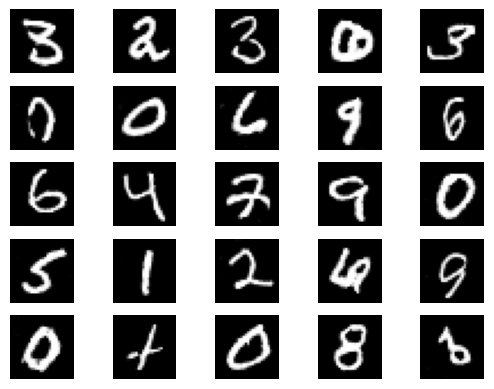

In [ ]:
batch_size = 25
latent_size = 100

fixed_noise = torch.randn(batch_size, latent_size, 1, 1).to(device)
fake_images = netG(fixed_noise)
fake_images_np = fake_images.cpu().detach().numpy()
fake_images_np = fake_images_np.reshape(fake_images_np.shape[0], 28, 28)
R, C = 5, 5
for i in range(batch_size):
    plt.subplot(R, C, i + 1)
    plt.axis('off')
    plt.imshow(fake_images_np[i], cmap='gray')
plt.show()

## 顯示 GIF 檔

In [27]:
# 安裝產生 GIF 檔的套件
!pip install -q imageio

In [ ]:
# 產生 GIF 檔
anim_file = './gan_output/dcgan.gif'
with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = glob.glob('./gan_output/fake_samples*.png')
    filenames = sorted(filenames)
    for filename in filenames:
        image = imageio.imread(filename)
        cast(imageio.core.format.Format.Writer, writer).append_data(image)

/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_91611/2489503981.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


<img src="./gan_output/dcgan.gif" align="left">